# Preprocessing the light curves — video

Give it **one FITS file** and **one light-curve JSON** in the config cell, run the load cells,
then the animation is built from there (instructions to follow).

## Config — set the two input files here

In [1]:
FITS_PATH    = "../mock_data/OBS_testCAM-i_ps_macro_noiseless.fits"   # lens-system image
LC_JSON_PATH = "../mock_data/testCAM-i_LC_sampled.json"               # sampled light curves

# truth file — only used for the "true Δt aligns the curves" diagnostic below
TRUTH_JSON_PATH = "../mock_data/multiple_images.json"                 # carries the real dt per image

## Imports

In [2]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from astropy.io import fits

## Plotting theme

In [3]:
# --- "tron" plotting theme, inlined so no pretty_plot install is needed -----
# (this is exactly what `pretty_plot.use("tron", font_scale=1.0)` applies)
import matplotlib as mpl

_FG, _BG = "#CDECF7", "#0A1721"
TRON_CYCLE = ["#00E8F8", "#FFA300", "#7DF9FF", "#37C0DC", "#EC7600", "#B7F7FF", "#2A6F97"]

plt.style.use("dark_background")
mpl.rcParams.update({
    # colours
    "figure.facecolor": _BG, "axes.facecolor": _BG, "savefig.facecolor": _BG,
    "text.color": _FG, "axes.labelcolor": _FG, "axes.titlecolor": _FG,
    "axes.edgecolor": "#2E6E8E", "xtick.color": _FG, "ytick.color": _FG,
    "axes.prop_cycle": mpl.cycler(color=TRON_CYCLE),
    # grid (tron turns it on, cyan-matched)
    "axes.grid": True, "grid.color": "#12384A", "grid.linewidth": 0.8, "grid.alpha": 0.7,
    # lines / ticks
    "lines.linewidth": 2.0, "lines.markersize": 5, "errorbar.capsize": 3,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1, "ytick.major.width": 1.1,
    "xtick.major.size": 5, "ytick.major.size": 5,
    # fonts: medium sans body, bold titles/labels, Computer-Modern maths
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "TeX Gyre Heros", "DejaVu Sans"],
    "font.weight": "medium",
    "axes.titleweight": "bold", "axes.labelweight": "bold", "figure.titleweight": "bold",
    "axes.titlepad": 10, "axes.labelpad": 6, "mathtext.fontset": "cm",
    "font.size": 13, "axes.titlesize": 17, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 13, "legend.title_fontsize": 13, "figure.titlesize": 18,
    # legend: opaque framed box so it reads over busy plots
    "legend.frameon": True, "legend.framealpha": 0.92,
    "legend.facecolor": _BG, "legend.edgecolor": "#00E8F8", "legend.fancybox": True,
    "legend.borderpad": 0.6, "legend.labelspacing": 0.5, "legend.handlelength": 1.8,
    # figure size for this notebook
    "figure.figsize": (11, 5),
})

PALETTE = [c["color"] for c in plt.rcParams["axes.prop_cycle"]]

## Read the FITS file

In [4]:
with fits.open(FITS_PATH) as hdul:
    hdul.info()
    LENS_IMG    = np.asarray(hdul[0].data, float)
    LENS_HEADER = hdul[0].header

try:
    LENS_EXTENT = [float(LENS_HEADER[k]) for k in ("XMIN", "XMAX", "YMIN", "YMAX")]
except KeyError:
    LENS_EXTENT = None

print("\nimage shape :", LENS_IMG.shape)
print("value range :", LENS_IMG.min(), "->", LENS_IMG.max())
print("extent      :", LENS_EXTENT)

Filename: ../mock_data/OBS_testCAM-i_ps_macro_noiseless.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      12   (100, 100)   float32   
  1  NEW-EXTENSION    1 ImageHDU         9   (100, 100)   float32   

image shape : (100, 100)
value range : 0.019733885303139687 -> 15.71733283996582
extent      : [-1.75, 1.75, -1.75, 1.75]



image shape : (100, 100)
value range : 0.019733885303139687 -> 15.71733283996582
extent      : [-1.75, 1.75, -1.75, 1.75]


## Read the light-curve JSON

In [5]:
LC_RAW = json.loads(Path(LC_JSON_PATH).read_text())

print(f"{len(LC_RAW)} entries; keys per entry: {sorted(LC_RAW[0].keys())}")
for idx, entry in enumerate(LC_RAW):
    t = np.asarray(entry["time"], float)
    s = np.asarray(entry["signal"], float)
    print(f"  [{idx}]  n={t.size:4d}   t: {t.min():.0f}–{t.max():.0f} d   "
          f"mag: {s.min():.2f}–{s.max():.2f}")

5 entries; keys per entry: ['dsignal', 'signal', 'time']
  [0]  n= 707   t: 1200–4287 d   mag: 22.73–23.23
  [1]  n= 707   t: 1200–4287 d   mag: 25.18–25.57
  [2]  n= 707   t: 1200–4287 d   mag: 34.81–35.21
  [3]  n= 707   t: 1200–4287 d   mag: 23.18–23.58
  [4]  n= 707   t: 1200–4287 d   mag: 23.79–24.22


## The lens system and the sampled light curves

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, n

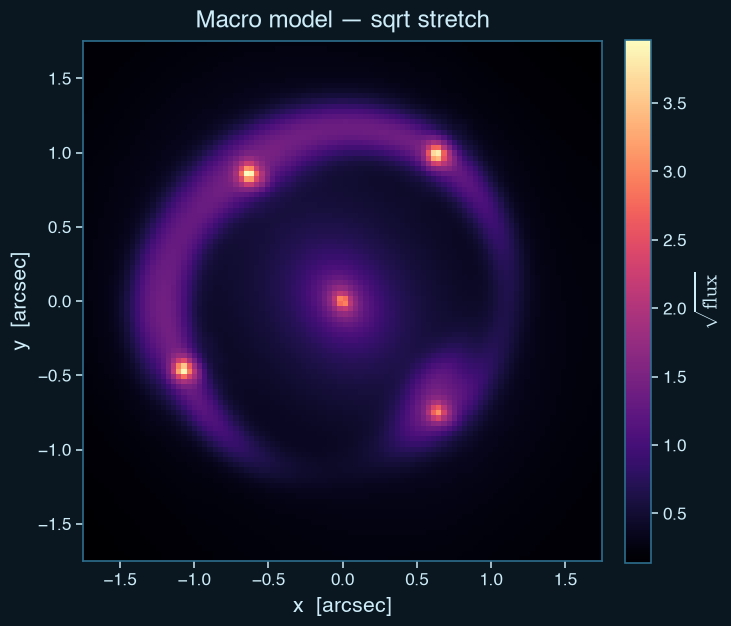

In [6]:
# --- the macro image, sqrt stretch (Niks solution) -------------------------
fig, ax = plt.subplots(figsize=(7.5, 7))
im = ax.imshow(np.sqrt(LENS_IMG), origin="lower", extent=LENS_EXTENT, cmap="magma")
ax.set_xlabel("x  [arcsec]")
ax.set_ylabel("y  [arcsec]")
ax.set_title("Macro model — sqrt stretch")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"$\sqrt{\mathrm{flux}}$")
fig.tight_layout()
plt.show()

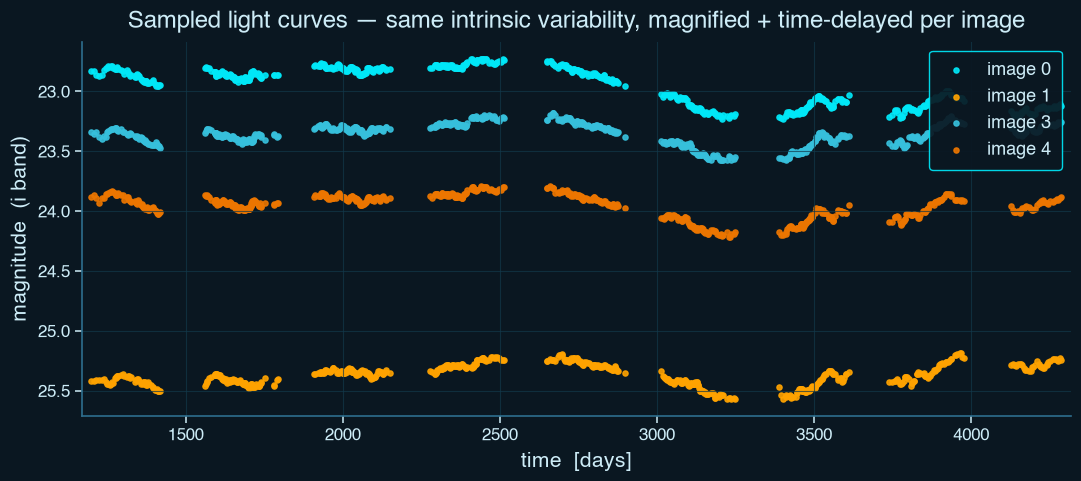

In [7]:
from matplotlib.ticker import AutoMinorLocator

KEEP = [0, 1, 3, 4]        # JSON index 2 is the central demagnified image (not observed)


def prettify(ax):
    """Light finishing touches shared by every axes (Niks solution)."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which="minor", length=0)
    ax.margins(x=0.01)
    return ax


# scatter of the sampled light curves - one colour per image (error column ignored)
fig, ax = plt.subplots()

for idx in KEEP:
    lc = LC_RAW[idx]
    ax.scatter(lc["time"], lc["signal"], s=14, color=PALETTE[idx % len(PALETTE)],
               alpha=0.9, label=f"image {idx}")

ax.invert_yaxis()                       # magnitudes: brighter is up
ax.set_xlabel("time  [days]")
ax.set_ylabel("magnitude  (i band)")
ax.set_title("Sampled light curves — same intrinsic variability, magnified + time-delayed per image")
ax.legend(loc="upper right")
prettify(ax)
fig.tight_layout()
plt.show()

### Sanity check — shifting each curve by its *true* Δt lines the variability up

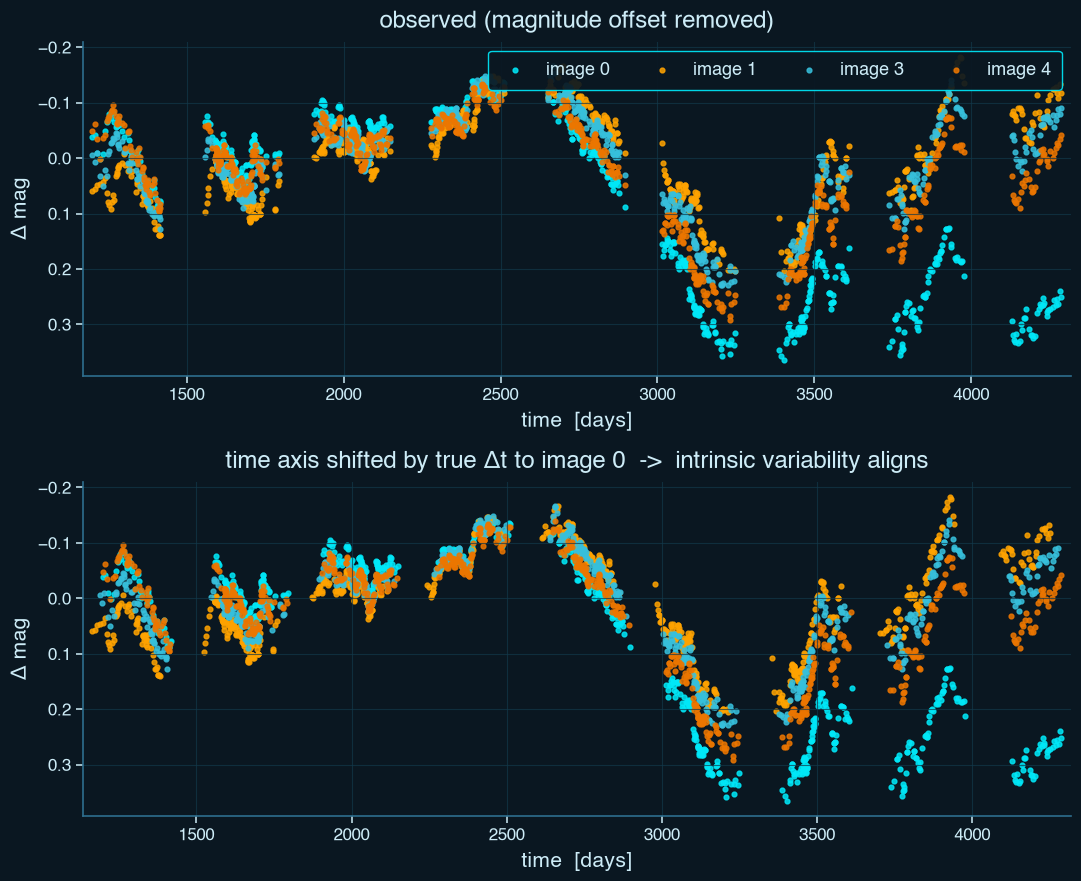

In [8]:
TRUTH = json.loads(Path(TRUTH_JSON_PATH).read_text())
dt = [im["dt"] for im in TRUTH]           # true time delay of each image [days]

ref = KEEP[0]                             # align everything to this image

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 9), sharex=False)

for idx in KEEP:
    lc = LC_RAW[idx]
    c = PALETTE[idx % len(PALETTE)]
    t = np.asarray(lc["time"], float)
    y = np.asarray(lc["signal"], float) - np.median(lc["signal"])   # drop the per-image magnification offset
    a1.scatter(t, y, s=12, color=c, alpha=0.85, label=f"image {idx}")
    a2.scatter(t - (dt[idx] - dt[ref]), y, s=12, color=c, alpha=0.85, label=f"image {idx}")

a1.set_title("observed (magnitude offset removed)")
a2.set_title(f"time axis shifted by true Δt to image {ref}  ->  intrinsic variability aligns")
for a in (a1, a2):
    a.invert_yaxis()
    a.set_xlabel("time  [days]")
    a.set_ylabel("Δ mag")
    prettify(a)
a1.legend(loc="upper right", ncol=4)
fig.tight_layout()
plt.show()

## The video

Built in one cell so we can keep re-cutting it. So far:

1. the macro image fades up — same look as the sqrt-stretch plot above (no title),
2. rings pop in around the observed point-source images, each in that image's light-curve colour (the central one is left alone),
3. the panel zooms out and glides to the left of the frame,
4. on the right, the sampled light curves fill in **in observation-time order** — a vertical cursor sweeps the survey window as the points arrive (the JSON `dsignal` column is a placeholder, not a real error, so no error bars).

In [9]:
from matplotlib.patches import Circle
from matplotlib import image as mpimg
from scipy.ndimage import label, center_of_mass
from IPython.display import Video

VIDEO_MP4 = "preprocessing.mp4"
LOGO_PATH = "../../assets/logo_w_text_w_highres.png"
FPS       = 30
DPI       = 140
FIG_W, FIG_H = 12.5, 7.0

# one clearly distinct hue per image — the theme cycle reuses near-identical
# blues/oranges, so images 0 & 3 (and 1 & 4) would otherwise be indistinguishable
_PT_COLOR = {0: "#00E8F8",   # cyan
             1: "#FFA300",   # amber
             3: "#C77DFF",   # violet
             4: "#4DF0A0"}   # mint

# --- locate the point-source images in the macro frame -------------------
_ny, _nx = LENS_IMG.shape


def _pix_to_sky(r, c):
    x = LENS_EXTENT[0] + (c + 0.5) * (LENS_EXTENT[1] - LENS_EXTENT[0]) / _nx
    y = LENS_EXTENT[2] + (r + 0.5) * (LENS_EXTENT[3] - LENS_EXTENT[2]) / _ny
    return x, y


_lab, _n = label(LENS_IMG > 4.0)
SOURCES  = [_pix_to_sky(r, c) for r, c in center_of_mass(LENS_IMG, _lab, range(1, _n + 1))]

# truth catalogue: image positions (to colour the rings) and time delays (Step 2 morph)
_TRUTH   = json.loads(Path(TRUTH_JSON_PATH).read_text())
_TRUTH_XY = {i: (t["x"], t["y"]) for i, t in enumerate(_TRUTH)}
_DT       = {i: t["dt"] for i, t in enumerate(_TRUTH)}                     # true time delay [days]
_CENTRAL  = min(_TRUTH_XY, key=lambda i: np.hypot(*_TRUTH_XY[i]))          # demagnified image at frame centre

RINGS = []                                                                # (x, y, colour) per observed image
for sx, sy in SOURCES:
    idx = min(_TRUTH_XY, key=lambda i: np.hypot(sx - _TRUTH_XY[i][0], sy - _TRUTH_XY[i][1]))
    if idx == _CENTRAL:
        continue
    RINGS.append((sx, sy, _PT_COLOR[idx]))

RING_R = 0.14                                                             # final ring radius [arcsec]

# --- right-panel light curves, ordered by observation time --------------
# (the JSON `dsignal` column is a placeholder ~= the magnitude itself, not a real
#  uncertainty, so no error bars — just the sampled points as they come in)
LCS = {}
for idx in KEEP:
    lc = LC_RAW[idx]
    t = np.asarray(lc["time"], float)
    y = np.asarray(lc["signal"], float)
    o = np.argsort(t)
    LCS[idx] = (t[o], y[o], _PT_COLOR[idx])

_REF   = KEEP[0]                                                          # align the shift to this image
_MED   = {idx: np.median(LCS[idx][1]) for idx in KEEP}                    # per-image magnification offset
_SHIFT = {idx: _DT[idx] - _DT[_REF] for idx in KEEP}                      # time shift applied in Step 2
_SHMAX, _SHMIN = max(_SHIFT.values()), min(_SHIFT.values())
_TALL  = np.concatenate([LCS[i][0] for i in KEEP])
_YMIN  = min(LCS[i][1].min() for i in KEEP)
_YMAX  = max(LCS[i][1].max() for i in KEEP)
_S1MIN = min((LCS[i][1] - _MED[i]).min() for i in KEEP)                   # range after the offset is removed
_S1MAX = max((LCS[i][1] - _MED[i]).max() for i in KEEP)
T0, T1 = _TALL.min(), _TALL.max()

_ease = lambda u: u * u * (3 - 2 * u)
_lerp = lambda a, b, u: a + (b - a) * u

# --- storyboard (transitions kept deliberately unhurried) --------------
FADE_IN     = int(0.7 * FPS)               # macro image fades up
HOLD        = int(0.5 * FPS)
STAGGER     = int(0.18 * FPS)              # gap between successive rings
POP         = int(0.45 * FPS)              # one ring's pop-in
RINGS_HOLD  = int(0.8 * FPS)
MOVE        = int(2.2 * FPS)               # zoom out + glide to the left
REVEAL      = int(4.5 * FPS)               # light curves come in "in real time"
MORPH_HOLD  = int(0.9 * FPS)               # beat with every point on screen
MORPH       = int(3.0 * FPS)               # Step 1: points slide to y - median
MORPH2_HOLD = int(1.1 * FPS)
MORPH2      = int(3.0 * FPS)               # Step 2: time axis shifted by true Δt
TAIL        = int(1.6 * FPS)

_RINGS_END    = FADE_IN + HOLD + STAGGER * (len(RINGS) - 1) + POP
_MOVE_START   = _RINGS_END + RINGS_HOLD
_REVEAL_START = _MOVE_START + MOVE
_MORPH_START  = _REVEAL_START + REVEAL + MORPH_HOLD
_MORPH2_START = _MORPH_START + MORPH + MORPH2_HOLD
N_FRAMES      = _MORPH2_START + MORPH2 + TAIL

# --- figure: left = the sqrt-stretch macro plot, right = the light curves ---
fig = plt.figure(figsize=(FIG_W, FIG_H))
ax  = fig.add_axes([0.24, 0.09, 0.40, 0.84])       # starts large & ~centred (looks like the plot)
_img = ax.imshow(np.sqrt(LENS_IMG), origin="lower", extent=LENS_EXTENT, cmap="magma",
                 interpolation="bilinear")
ax.set_xlabel("x  [arcsec]")
ax.set_ylabel("y  [arcsec]")
ax.grid(False)
ax.set_anchor("C")
_cbar = fig.colorbar(_img, ax=ax, fraction=0.046, pad=0.04, label=r"$\sqrt{\mathrm{flux}}$")
fig.canvas.draw()

# left panel: start = as laid out  ->  end = shrunk, parked on the far left
_AX0 = ax.get_position().bounds
_CB0 = _cbar.ax.get_position().bounds

_H1 = 0.46                          # parked thumbnail: bigger, since it loses ticks + labels
_W1 = _H1 * FIG_H / FIG_W
_L1 = 0.020
_B1 = (1.0 - _H1) / 2
_AX1 = (_L1, _B1, _W1, _H1)
_CB1 = (_L1 + _W1 + 0.006, _B1, 0.013, _H1)

# left panel zoom-out
_FX = (LENS_EXTENT[0], LENS_EXTENT[1])
_FY = (LENS_EXTENT[2], LENS_EXTENT[3])
_cx, _cy = sum(_FX) / 2, sum(_FY) / 2
_Z = 1.55
_ZX = (_cx + (_FX[0] - _cx) * _Z, _cx + (_FX[1] - _cx) * _Z)
_ZY = (_cy + (_FY[0] - _cy) * _Z, _cy + (_FY[1] - _cy) * _Z)

_rings = [Circle((x, y), RING_R, fill=False, lw=2.4, ec=col, visible=False)
          for x, y, col in RINGS]
for _c in _rings:
    ax.add_patch(_c)

# right panel: fixed wide axes, y-axis parked right next to the (now bare) image;
# points accumulate in observation-time order
ax2 = fig.add_axes([0.33, 0.12, 0.64, 0.80])
ax2.set_visible(False)

# --- watermark logo, bottom-left (fixed, drawn once, never cleared) -----
_LOGO = mpimg.imread(LOGO_PATH).astype(float)
if _LOGO.max() > 1.0:
    _LOGO /= 255.0
if _LOGO.shape[-1] == 4:
    _LOGO[..., 3] *= 0.55                                   # semi-transparent
_lh, _lw = _LOGO.shape[:2]
_WM_W = 0.135
_WM_H = _WM_W * (_lh / _lw) * (FIG_W / FIG_H)               # keep the logo's aspect
_wm_ax = fig.add_axes([0.012, 0.012, _WM_W, _WM_H], zorder=12)
_wm_ax.imshow(_LOGO)
_wm_ax.axis("off")
_wm_ax.patch.set_alpha(0.0)


def _style_ax2(q=0.0, w=0.0):
    """q: 0 raw -> 1 offset removed.   w: 0 observed time -> 1 shifted by true Δt."""
    if w >= 0.5:
        ttl = r"Time axis shifted by true $\Delta t$"
    elif q >= 0.5:
        ttl = "Magnitude offset removed"
    else:
        ttl = "Sampled light curves"
    ax2.set_title(ttl)
    ax2.set_xlabel("time  [days]" if w < 0.5 else r"time $-\ (\Delta t_i - \Delta t_{\mathrm{ref}})$   [days]")
    ax2.set_ylabel("magnitude  (i band)" if q < 0.5 else r"$\Delta$ mag")
    prettify(ax2)
    ax2.set_xlim(_lerp(T0 - 40, T0 - _SHMAX - 30, w),
                 _lerp(T1 + 40, T1 - _SHMIN + 30, w))
    ax2.set_ylim(_lerp(_YMAX + 0.06, _S1MAX + 0.06, q),
                 _lerp(_YMIN - 0.06, _S1MIN - 0.06, q))    # inverted: brighter is up


def _fade_cbar(a):
    """Fade the whole colorbar out (a -> 0) so the parked image stands alone."""
    _cbar.solids.set_alpha(a)
    _cbar.outline.set_alpha(a)
    _cbar.ax.yaxis.label.set_alpha(a)
    for _t in _cbar.ax.get_yticklabels():
        _t.set_alpha(a)
    _cbar.ax.tick_params(length=2.5 * a)


def _fade_ax_frame(a):
    """Fade the macro axes' spines, labels, ticks & tick numbers out (a -> 0)."""
    for sp in ax.spines.values():
        sp.set_alpha(a)
    ax.xaxis.label.set_alpha(a)
    ax.yaxis.label.set_alpha(a)
    for _t in (*ax.get_xticklabels(), *ax.get_yticklabels()):
        _t.set_alpha(a)
    ax.tick_params(length=4.5 * a, width=1.1 * a)


def _frame(f):
    _img.set_alpha(_ease(np.clip(f / FADE_IN, 0, 1)))

    r0 = FADE_IN + HOLD
    for k, c in enumerate(_rings):
        u = _ease(np.clip((f - (r0 + k * STAGGER)) / POP, 0, 1))
        c.set_visible(u > 0)
        if u > 0:
            c.set_radius(RING_R * (2.4 - 1.4 * u))
            c.set_alpha(u)

    m = _ease(np.clip((f - _MOVE_START) / MOVE, 0, 1))
    ax.set_position([_lerp(a, b, m) for a, b in zip(_AX0, _AX1)])
    _cbar.ax.set_position([_lerp(a, b, m) for a, b in zip(_CB0, _CB1)])
    _fade_cbar(1 - m)
    _fade_ax_frame(1 - m)                    # spines, "x/y [arcsec]", ticks & numbers all go
    ax.set_xlim(_lerp(_FX[0], _ZX[0], m), _lerp(_FX[1], _ZX[1], m))
    ax.set_ylim(_lerp(_FY[0], _ZY[0], m), _lerp(_FY[1], _ZY[1], m))

    if f >= _REVEAL_START:
        fr = f - _REVEAL_START
        if fr < REVEAL:                                       # points arrive "in real time"
            tc = T0 + (T1 - T0) * np.clip(fr / REVEAL, 0, 1)
            q = w = 0.0
        else:
            tc = T1
            q = _ease(np.clip((f - _MORPH_START)  / MORPH,  0, 1))   # Step 1: y - median
            w = _ease(np.clip((f - _MORPH2_START) / MORPH2, 0, 1))   # Step 2: t - Δt

        ax2.set_visible(True)
        ax2.clear()
        for idx in KEEP:
            t, y, col = LCS[idx]
            sel = t <= tc
            ax2.scatter((t - w * _SHIFT[idx])[sel], (y - q * _MED[idx])[sel],
                        s=14, color=col, alpha=0.9, label=f"image {idx}")
        if q < 1:
            ax2.axvline(tc, color=_FG, lw=1.0, alpha=0.30 * (1 - q))
        _style_ax2(q, w)
        ax2.legend(loc="upper right", ncol=2, fontsize=10)

    return [_img, *_rings]


anim = animation.FuncAnimation(fig, _frame, frames=N_FRAMES,
                               interval=1000 / FPS, blit=False)
anim.save(VIDEO_MP4, writer="ffmpeg", fps=FPS, dpi=DPI)
plt.close(fig)
print(f"saved {VIDEO_MP4}   ({N_FRAMES} frames, {N_FRAMES / FPS:.1f} s)")

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight bold, now using 400.


saved preprocessing.mp4   (577 frames, 19.2 s)


In [10]:
Video(VIDEO_MP4, embed=True, width=800)